In [1]:
import pandas as pd
import numpy as np
import re
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter
from matplotlib import pyplot as plt

In [3]:
df_true = pd.read_csv("True.csv")
df_fake = pd.read_csv("Fake.csv")

df_true['label'] = 1
df_fake['label'] = 0

df = pd.concat([df_true, df_fake], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df['content'] = df['title'] + ' ' + df['text']
df = df[['content', 'label']]

In [4]:
df

,content,label
0,BREAKING: GOP Chairman Grassley Has Had Enoug...,0
1,Failed GOP Candidates Remembered In Hilarious...,0
2,Mike Pence’s New DC Neighbors Are HILARIOUSLY...,0
3,California AG pledges to defend birth control ...,1
4,AZ RANCHERS Living On US-Mexico Border Destroy...,0
...,...,...
44893,Nigeria says U.S. agrees delayed $593 million ...,1
44894,Boiler Room #62 – Fatal Illusions Tune in to t...,0
44895,ATHEISTS SUE GOVERNOR OF TEXAS Over Display on...,0
44896,Republican tax plan would deal financial hit t...,1


In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub('<.*?>', ' ', text)
    text = re.sub('[^a-zA-Z]', ' ', text)
    text = re.sub('\s+', ' ', text).strip()
    return text

df['content'] = df['content'].apply(clean_text)

<>:5: SyntaxWarning: invalid escape sequence '\s'
<>:5: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_535/3861500990.py:5: SyntaxWarning: invalid escape sequence '\s'
  text = re.sub('\s+', ' ', text).strip()


In [6]:
df['tokens'] = df['content'].apply(lambda x: x.split())

all_words = [word for tokens in df['tokens'] for word in tokens]
word_counts = Counter(all_words)

vocab_size = 20000
vocab = ['<PAD>', '<UNK>'] + [word for word, count in word_counts.most_common(vocab_size)]
word2idx = {word: idx for idx, word in enumerate(vocab)}

In [7]:
def encode(tokens):
    return [word2idx.get(word, 1) for word in tokens]

df['encoded'] = df['tokens'].apply(encode)

In [8]:
max_len = 500

def pad_sequence(seq, max_len):
    if len(seq) >= max_len:
        return seq[:max_len]
    return seq + [0] * (max_len - len(seq))

df['padded'] = df['encoded'].apply(lambda x: pad_sequence(x, max_len))

In [9]:
print(df['padded'][0])
print(len(df['padded'][0]))

[1148, 432, 603, 3435, 22, 44, 482, 2027, 13, 1326, 1744, 72, 13, 8, 85, 70, 12, 7, 2150, 6, 31, 29, 384, 3, 1152, 15, 62, 43, 136, 1113, 29, 5462, 21, 2, 1454, 6, 31, 2679, 3, 4377, 9, 63, 29, 1113, 2394, 57, 4, 27, 3, 94, 15, 8, 618, 98, 49, 5, 4416, 315, 2, 1348, 3697, 360, 56, 5829, 6, 15, 830, 9, 63, 29, 101, 11068, 7, 2, 600, 179, 898, 1989, 3435, 959, 1450, 30, 1966, 2, 158, 1763, 228, 12, 1721, 62, 14, 12, 101, 2408, 9, 72, 13, 1326, 6, 109, 13, 93, 1456, 593, 1725, 3008, 119, 20, 228, 1304, 2, 101, 4658, 6882, 265, 170, 72, 13, 6, 2, 6882, 192, 865, 30, 1338, 6310, 10, 164, 154, 437, 107, 68, 7, 297, 27, 291, 12, 576, 177, 101, 27, 1516, 4888, 5, 449, 5551, 3, 463, 13, 126, 5184, 9, 31, 115, 24, 725, 511, 1282, 1024, 1275, 151, 103, 2958, 495, 2, 297, 9, 15, 830, 9, 27, 830, 3, 23, 59, 13, 8, 85, 70, 12, 6056, 2, 10654, 73, 3, 965, 3, 92, 19, 34, 965, 143, 12, 2, 724, 1304, 3435, 8, 1471, 65, 518, 30, 1382, 9, 245, 3435, 6, 2, 1254, 4, 2, 158, 29, 24, 853, 40, 27, 106, 658, 3,

In [10]:
X = np.array(df['padded'].tolist())
y = np.array(df['label'].tolist())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [11]:
class FakeGuardLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(hidden_dim, output_dim)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)
        out, (hidden, cell) = self.lstm(x)
        out = out[:, -1, :]
        out = self.dropout(out)
        out = self.sigmoid(self.fc(out))
        return out

In [12]:
VOCAB_SIZE = len(word2idx)
EMBED_DIM = 64
HIDDEN_DIM = 128
OUTPUT_DIM = 1

model = FakeGuardLSTM(VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, OUTPUT_DIM)

In [13]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
model = model.to(device)

Using device: cuda


In [14]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(),lr = 0.001)

Epoch 1/50 | Avg Loss: 0.6955
Epoch 2/50 | Avg Loss: 0.6343
Epoch 3/50 | Avg Loss: 0.5540
Epoch 4/50 | Avg Loss: 0.3854
Epoch 5/50 | Avg Loss: 0.3521
Epoch 6/50 | Avg Loss: 0.4449
Epoch 7/50 | Avg Loss: 0.3182
Epoch 8/50 | Avg Loss: 0.1364
Epoch 9/50 | Avg Loss: 0.4028
Epoch 10/50 | Avg Loss: 0.2012
Epoch 11/50 | Avg Loss: 0.1003
Epoch 12/50 | Avg Loss: 0.0552
Epoch 13/50 | Avg Loss: 0.0306
Epoch 14/50 | Avg Loss: 0.0223
Epoch 15/50 | Avg Loss: 0.0191
Epoch 16/50 | Avg Loss: 0.0239
Epoch 17/50 | Avg Loss: 0.0129
Epoch 18/50 | Avg Loss: 0.0132
Epoch 19/50 | Avg Loss: 0.0126
Epoch 20/50 | Avg Loss: 0.0084
Epoch 21/50 | Avg Loss: 0.0077
Epoch 22/50 | Avg Loss: 0.0078
Epoch 23/50 | Avg Loss: 0.0045
Epoch 24/50 | Avg Loss: 0.0045
Epoch 25/50 | Avg Loss: 0.0040
Epoch 26/50 | Avg Loss: 0.0040
Epoch 27/50 | Avg Loss: 0.0033
Epoch 28/50 | Avg Loss: 0.0041
Epoch 29/50 | Avg Loss: 0.0044
Epoch 30/50 | Avg Loss: 0.0033
Epoch 31/50 | Avg Loss: 0.0033
Epoch 32/50 | Avg Loss: 0.0024
Epoch 33/50 | Avg

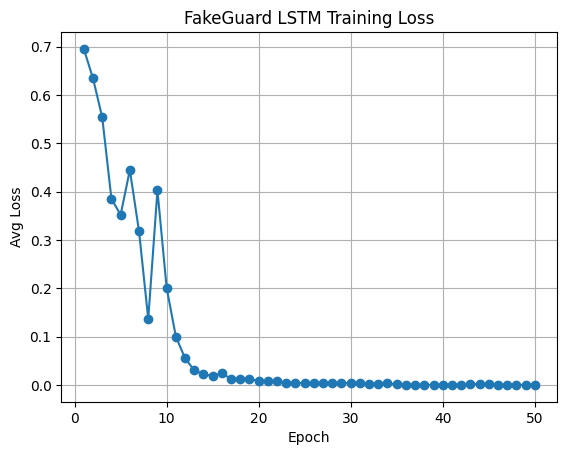

In [15]:
epochs = 50

loss_history = []

for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, y_batch)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    loss_history.append(avg_loss)
    print(f'Epoch {epoch+1}/{epochs} | Avg Loss: {avg_loss:.4f}')

plt.plot(range(1, epochs+1), loss_history, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Avg Loss')
plt.title('FakeGuard LSTM Training Loss')
plt.grid(True)
plt.show()

In [16]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)
        output = model(X_batch)
        predicted = (output > 0.5).float()
        correct += (predicted == y_batch).sum().item()
        total += y_batch.size(0)

print(f'Accuracy: {100 * correct / total:.2f}%')

Accuracy: 99.89%


In [18]:
torch.save(model.state_dict(), 'fakeguard_lstm.pth')
from google.colab import files
files.download('fakeguard_lstm.pth')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>